## Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2

## MODEL DEFINITION
We consider an individual-based evolutionary model of an asexual population of constant size N, evolving under a non-neutral Moran process. Each individual
i is characterized by:
- a phenotypic vector $z_i∈R^d$, where  d is the phenotypic dimensionality (complexity);
- a binary mutator allele $m_i∈{0,1}$, where $m_i=1$ indicates a mutator individual and $m_i=0$ a wild type.

The environment is defined by an optimal phenotype $z^∗$, which can be constant or moving with the following linear law:
$z^*(t) = \mathbf{v}\, t,$
where $\mathbf{v}$ is a constant velocity in phenotype space, which determines both the speed and direction of adaptation. In particular $\mathbf{v} = (v_1, 0, 0, ...)$. On the other hand, t is the number of Moran steps. The optimum is updated every 5000 steps in order to have a stepwise moving optimum.
To ensure more closeness to reality we impose that the change occurs after a constant interval of time.

Fitness is determined by Fisher’s Geometrical Model through a Gaussian stabilizing selection function:
$
w(z)=exp⁡ ⁣(\frac{−∥z−z^∗∥^2}{2σ^2}),
$

where σ controls the width of the fitness peak.

At each Moran step:

- one individual reproduces with probability proportional to its fitness;
- one individual is removed uniformly at random;
- the offspring inherits the parent’s phenotype and mutator status, subject to mutation.

Mutations occur with probability
$
\mu =
\begin{cases}
\mu_{\mathrm{WT}}, & \text{if } m = 0, \\
\alpha\,\mu_{\mathrm{WT}}, & \text{if } m = 1,
\end{cases}
$

where
α≫1 is the mutator strength. When a mutation occurs, the phenotype is updated as
$ z′=z+δ$, where
$
\delta_j ∼
\begin{cases}
N(0,η^2), & \text{if } j \in I, |I| = k, \\
0, & \text{otherwise} ,
\end{cases}
$

meaning that each mutation affects exactly k $\leq$ d phenotypic traits (partial pleiotropy), the k affected dimensions are chosen uniformly at random among the d traits, and mutational effects on each affected trait are independently drawn from a normal distribution.

In [ ]:
# FUNCTION zopt_constant
# Returns a function that provides a fixed phenotypic optimum.

# INPUTS
# z0 : array-like, shape (d,). Fixed optimal phenotype.

# OUTPUT
# zopt : Function zopt(t) returning the same optimum at all times.


def zopt_constant(z0):
    def zopt(t):
        return z0
    return zopt

# FUNCTION moving_zopt
# Returns a function that provides a moving phenotypic optimum.

# INPUTS
# z0 : array-like, shape (d,). Initial position of the optimum phenotype, at time z.
# v: array-like, shape (d,). Constant velocity of the moving optimum.

# OUTPUT
# zopt : Function zopt(t) returning the optimum moving position at times t.

def moving_zopt(z0,v):
  def zopt(t):
      return z0+v*t
  return zopt

# FUNCTION mutate_subset
# Applies a mutation affecting a random subset of phenotypic dimensions.

# INPUTS
# z : array-like, shape (d,). Parental phenotype.
# eta : float. Standard deviation of mutational effects.
# k: integer. Mutational pleiotropy, i.e. the number of traits that simultanously can be affected by a mutation
# rng : numpy random generator or None

# OUTPUTS
# z_new : array-like, shape (d,). Mutated phenotype.
# idx : array-like. Indices of mutated dimensions.

def mutate_subset(z, eta, k=2, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    d = z.size
    # Effective mutational pleiotropy (if d <k)
    m_eff = min(k, d)

    # Randomly select which dimensions mutate
    idx = rng.choice(d, size=m_eff, replace=False)
    # Mutational displacement
    delta = np.zeros(d)
    delta[idx] = rng.normal(0, eta, size=m_eff)

    # Compute the mutated individual
    z_new = z + delta

    return z_new, idx


# FUNCTION moran_step
# Performs one Moran process step with selection and mutation.

# INPUTS
# Z : array-like, shape (N, d). Phenotype matrix.
# m : array-like, shape (N,). Mutator allele indicator (0 = WT, 1 = mutator).
# t : int. Current time step.
# zopt_fn : function. Returns optimal phenotype at time t.
# sigma : float. Fitness landscape width.
# mu_WT : float. Baseline mutation probability.
# alpha : float. Mutator multiplier (mu_mut = alpha * mu_WT).
# eta : float.  Mutation effect size.
# k : integer. Mutational pleiotropy, i.e. the number of traits that simultanously can be affected by a mutation
# rng : numpy random generator
# log : dict or None. Dictionary for logging mutation events:
#       t: time of mutation
#       beneficial: if the fitness after mutation is greater than the mean population fitness before the mutation.
#       s_parent: selective effect with respect to the parent
#       s_pop: selective effect with respect to the mean fitness of the population.

# OUTPUTS
# Z : updated phenotype matrix
# m : updated mutator allele vector
# z_opt : current optimum
# s_parent: selective effect with respect to the parent
# s_pop: selective effect with respect to the mean fitness of the population

def moran_step(
    Z, m, t,
    zopt_fn,
    sigma,
    mu_WT,
    alpha,
    eta,
    k=2,
    rng=None,
    log=None,
):
    if rng is None:
        rng = np.random.default_rng()

    N, d = Z.shape
    z_opt = zopt_fn(t)

    ## Compute fitness ##
    diff = Z - z_opt # (N,d)
    # Note: diff[i] is the displacement vector from individual i to the phenotypic optimum
    dist2 = np.sum(diff**2, axis=1) # (N, )
    # Note: axis=1: sum over phenotypic dimensions (squared Euclidean distance to the optimum)

    # Gaussian fitness according to the Fisher Geometrical Model
    w = np.exp(-dist2 / (2 * sigma**2)) # (N,)

    # Compute the probability of reproduction (proportional to fitness)
    probs = w / w.sum() if w.sum() > 0 else np.ones(N) / N

    # Reproduction: choose parent proportional to fitness
    parent = rng.choice(N, p=probs)
    # Death: choose uniformly an individual to die
    dead = rng.integers(0, N)

    # Offspring inherits phenotype and mutator allele
    z_parent = Z[parent].copy()
    z_new = z_parent.copy()
    m_new = m[parent]

    # Mutation step
    mu = mu_WT * (alpha if m_new == 1 else 1.0)
    did_mut = rng.random() < mu

    if did_mut:
        z_new, mut_idx = mutate_subset(
            z_new, eta=eta, k=k, rng=rng
        )

        ## Check if the mutation is beneficial ##
        # A mutation is classified as beneficial if its fitness
        # exceeds the mean population fitness before the Moran step


        # Fitness of the parent
        w_parent = w[parent]

        # Compute fitness of the new individual
        dist2_new = np.sum((z_new - z_opt)**2)
        w_new = np.exp(-dist2_new / (2 * sigma**2))

        # Compute mean fitness before Moran update
        w_bar = w.mean()


        # Handle cases where fitness might be zero to avoid log(0) warnings
        if w_new > 0 and w_parent > 0:
            s_parent = np.log(w_new) - np.log(w_parent)
        else:
            s_parent = -np.inf

        s_pop = np.log(w_new) - np.log(w_bar)

        is_beneficial = s_pop > 0


        # Log mutation events
        if log is not None:
            log["mutations"].append({
                "t": t,
                "beneficial": is_beneficial,
                "s_parent": s_parent,
                "s_pop": s_pop,
            })
    # Replace dead individual
    Z[dead] = z_new
    m[dead] = m_new

    return Z, m, z_opt



# FUNCTION run_simulation
# Runs an individual-based evolutionary simulation using a Moran process
# on a Fisher Geometrical Model fitness landscape.
# This function represents a single evolutionary experiment analogous
# to one chemostat competition in Chao & Cox (1983).

# INPUTS
# N : int. Population size (constant).
# d : int. Phenotypic dimensionality.
# T : int. Maximum number of time steps (Moran steps ≈ 1/N generations).
# f0_M : float. Initial frequency of the mutator allele.
# mu_WT : float. Baseline mutation rate for wild-type individuals.
# alpha : float. Mutator strength (mutation rate multiplier).
# eta : float. Standard deviation of mutational effects.
# sigma : float. Width of the fitness peak (strength of stabilizing selection).
# zopt_fn : function or None. Function returning the optimal phenotype at time t. If None, the optimum is constant (zopt = np.ones(d)).
# k : integer. Mutational pleiotropy, i.e. the number of traits that simultanously can be affected by a mutation
# seed : int or None. Random seed for reproducibility.
# stop_on_fixation : bool. Whether to stop the simulation early if the mutator fixes or goes extinct.
# w0_target: float. Initial fitness. it forces the population initialized in Z= 0 to have the same distance from the optimum. If None, the optimum is set z* = (1,…,1).

# OUTPUTS
# results : dict. Dictionary containing:
# - "freq_M": mutator frequency over time
# - "mean_fitness": mean population fitness over time
# - "zopt": trajectory of the phenotypic optimum
# - "log": mutation event log
# - "t_abs": time at which the trajectory reach an absorbent state (fixation or extinction)
# - "abs_state": the absorbent state reached
#

def run_simulation(
    N=500,
    d=2,
    T=20000,
    f0_M=0.01,
    mu_WT=1e-4,
    alpha=10,
    eta=0.1,
    sigma=1.0,
    zopt_fn=None,
    k=2,
    seed=None,
    stop_on_fixation=True,
    w0_target=None,
):

    rng = np.random.default_rng(seed)

     # Constant optimum with fixed initial fitness
    if zopt_fn is None:
        if w0_target is None:
             zstar = np.ones(d)
        else:
           # ||zstar||^2 = -2 sigma^2 log(w0_target)
           r2 = -2 * sigma**2 * np.log(w0_target)
           zstar = np.ones(d) * np.sqrt(r2 / d)
        zopt_fn = zopt_constant(zstar)

    # Initial population phenotypes (all zeros)
    Z = np.zeros((N, d), dtype=float)

    # Allele mutator
    m = np.zeros(N, dtype=int)
    n_mut = int(round(f0_M * N))
    if n_mut > 0:
        m[rng.choice(N, n_mut, replace=False)] = 1

    # Storage
    freq_M = np.zeros(T + 1)
    mean_fitness = np.zeros(T + 1)
    zopt_traj = np.zeros((T + 1, d))


    # log mutation events
    log = {"mutations": []}

    # t=0
    z_opt = zopt_fn(0)
    zopt_traj[0] = z_opt
    freq_M[0] = m.mean()

    # Compute fitness of all individuals (vectorial form)
    dist2_all = np.sum((Z - z_opt)**2, axis=1)
    w_all = np.exp(-dist2_all / (2 * sigma**2))

    # Mean fitness of the whole population
    mean_fitness[0] = np.mean(w_all)

    t_abs = None
    abs_state = None  # "fixation" or "extinction"

    # Main loop
    for t in range(1, T + 1):
        Z, m, z_opt = moran_step(
            Z, m, t,
            zopt_fn=zopt_fn,
            sigma=sigma,
            mu_WT=mu_WT,
            alpha=alpha,
            eta=eta,
            k=k,
            rng=rng,
            log=log,
        )

        zopt_traj[t] = z_opt
        freq_M[t] = m.mean()

        # Compute updated fitness
        diff = Z - z_opt
        dist2 = np.sum(diff**2, axis=1)
        w_all = np.exp(-dist2 / (2 * sigma**2))
        # Update mean_fitness
        mean_fitness[t] = w_all.mean()

        # Stop early if fixation/extinction
        if stop_on_fixation and (freq_M[t] == 0.0 or freq_M[t] == 1.0):
            t_abs = t
            abs_state = "extinction" if freq_M[t] == 0.0 else "fixation"

            # "fill tail" behavior
            freq_M[t:] = freq_M[t]
            mean_fitness[t:] = mean_fitness[t]
            zopt_traj[t:] = zopt_traj[t]
            break

    return {
        "freq_M": freq_M,
        "mean_fitness": mean_fitness,
        "zopt": zopt_traj,
        "log": log,
        "t_abs": t_abs,                 # Moran steps
        "abs_state": abs_state,
        "Z_final": Z.copy()
    }

## Explore the influence of $\sigma$

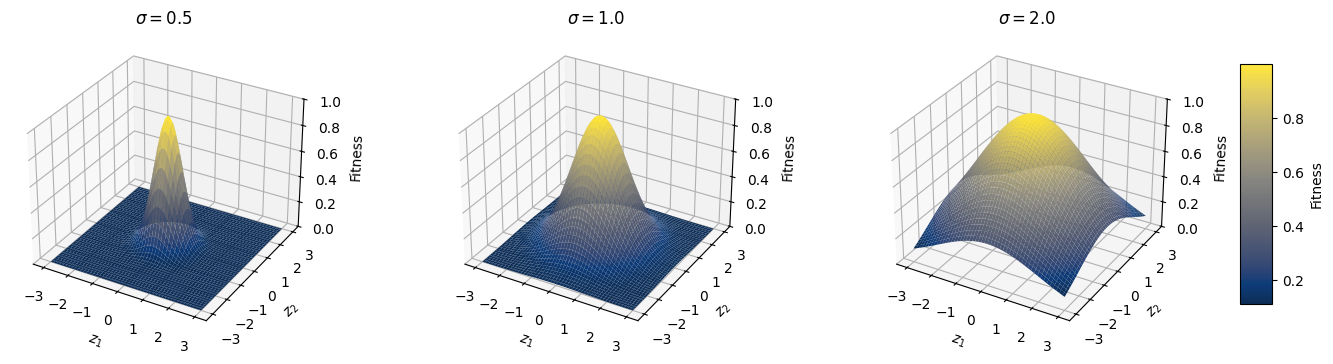

In [ ]:
def plot_fitness_landscape_3D_sigma(
    sigma_values,
    z_range=(-3, 3),
    n_grid=150,
):
    zmin, zmax = z_range
    x = np.linspace(zmin, zmax, n_grid)
    y = np.linspace(zmin, zmax, n_grid)
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=(5 * len(sigma_values) + 1.2, 4))

    axes = []
    mappable = None

    for i, sigma in enumerate(sigma_values):
        ax = fig.add_subplot(1, len(sigma_values), i + 1, projection="3d")
        axes.append(ax)

        Z = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

        surf = ax.plot_surface(
            X, Y, Z,
            cmap="cividis",
            edgecolor="none",
            alpha=0.95,
        )

        mappable = surf  # save last one for colorbar

        ax.set_zlim(0, 1)
        ax.set_title(rf"$\sigma = {sigma}$")
        ax.set_xlabel("$z_1$")
        ax.set_ylabel("$z_2$")
        ax.set_zlabel("Fitness")
        ax.view_init(elev=30, azim=-60)

    # space for colorbar
    fig.subplots_adjust(right=0.88)

    # axis for colorbar
    cax = fig.add_axes([0.9, 0.2, 0.02, 0.6])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label("Fitness")

    plt.show()
plot_fitness_landscape_3D_sigma([0.5, 1.0, 2.0])


## EXPERIMENT: Explore the effect of $f_{0,M}$ on the competition between mutator alleles and wild type ones

We decided to observe the competition between two strains with different
mutation rates
As Chao & Chox (1983) we focus on the log-ratio $R(t) = log_{10}(\frac{f_{MUT}(t)}{f_{WT}(t)})$ plotted against generations. All parameters are held fixed except the initial mutator frequenc $f_{0,M}$.
The goal is to assess whether our individual-based Moran implementation on a Fisher Geometrical Model landscape reproduces the qualitative regimes reported in the experimental study: an initial “lag” phase during which mutator and wild type coexist, followed by a rapid transition to fixation of one allele and extinction of the other once a sufficiently beneficial mutation arises and successfully hitchhikes.

In [ ]:
# FUNCTION log_ratio_mutT_mutp
# Computes the log-ratio between mutator and wild-type frequencies.

# INPUTS
# freq_M : array-like. Time series of mutator allele frequency f_M(t).
# eps : float. Small numerical constant used to avoid log(0) and division by zero, since f_M reaches 0 (extinction) or 1 (fixation).

# OUTPUTS
# log_ratio : array-like. Time series of log10(mutator / wild-type) ratios.

def log_ratio_mutT_mutp(freq_M, eps=1e-12):

    # Ensure numerical stability:
    # values of f_M equal to 0 or 1 would lead to infinities
    # in the log-ratio, so we restrict the frequency to (eps, 1 - eps)
    f = np.clip(freq_M, eps, 1 - eps)

    # Compute log10(mutator / wild-type) ratio
    # wild-type frequency is (1 - f)
    log_ratio = np.log10(f / (1 - f))

    return log_ratio


First try with low value of $f0_M$ and fixed seed = 3

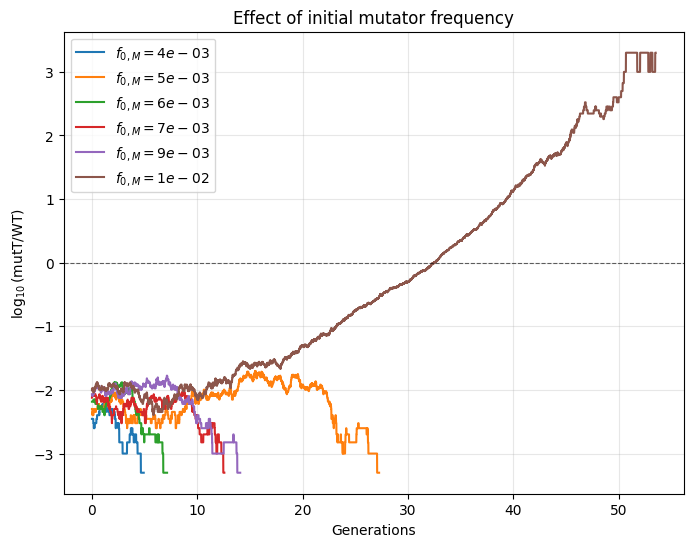

In [ ]:
# Possible choice of f0_M values
f0_M_values = [7/2000, 10/2000, 13/2000, 15/2000, 17/2000, 20/2000]

# Fix all the others parameters
base_sim_params = dict(
    N=2000,        # Population size
    d=2,           # Dimension of the phenotypic space
    T=2000*100,    # ~100 generations
    mu_WT=2e-4,    # mutation probability for wilde type
    alpha=200,     # mutator strength
    eta=0.1,
    k=2,
    stop_on_fixation=True,
)

plt.figure(figsize=(8,6))

for f in f0_M_values:
    params = base_sim_params.copy()
    params["f0_M"] = f

    results = run_simulation(**params, seed=3)
    freq_M = results["freq_M"]
    t_abs = results["t_abs"]

    freq = freq_M[:t_abs]
    eps = 1 / params["N"]
    R = log_ratio_mutT_mutp(freq,eps)
    # Convert time scale from Moran Step to Generations
    t = np.arange(len(R))
    G = t / params["N"]

    plt.plot(
        G,
        R,
        lw=1.5,
        label=rf"$f_{{0,M}} = {f:.0e}$"
    )

plt.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
plt.xlabel("Generations")
plt.ylabel(r"$\log_{10}(\mathrm{mutT}/\mathrm{WT})$")
plt.title("Effect of initial mutator frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Second try with low value of $f0_M$ and fixed seed = 1234

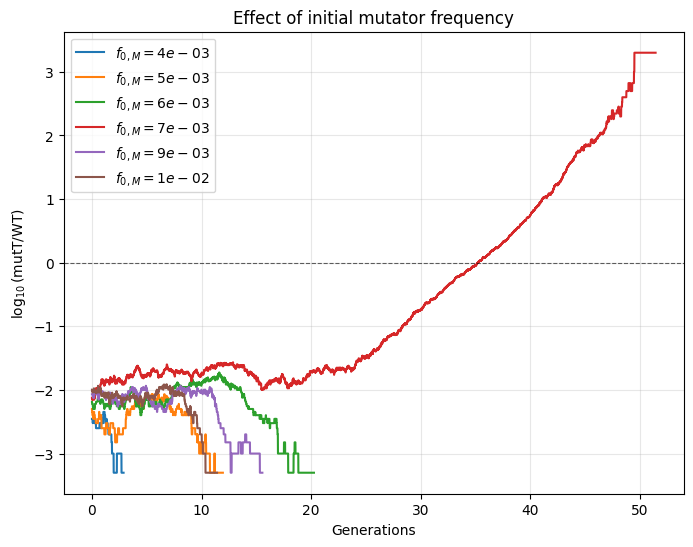

In [ ]:
# Possible choice of f0_M values
f0_M_values = [7/2000, 10/2000, 13/2000, 15/2000, 17/2000, 20/2000]

# Fix all the others parameters
base_sim_params = dict(
    N=2000,        # Population size
    d=2,           # Dimension of the phenotypic space
    T=2000*100,    # ~100 generations
    mu_WT=2e-4,
    alpha=200,     # mutator strength
    eta=0.1,
    k=2,
    stop_on_fixation=True,
)

plt.figure(figsize=(8,6))

for f in f0_M_values:
    params = base_sim_params.copy()
    params["f0_M"] = f

    results = run_simulation(**params, seed=1234)
    freq_M = results["freq_M"]
    t_abs = results["t_abs"]

    freq = freq_M[:t_abs]
    eps = 1 / params["N"]
    R = log_ratio_mutT_mutp(freq,eps)
    t = np.arange(len(R))
    G = t / params["N"]   # GENERATIONS

    plt.plot(
        G,
        R,
        lw=1.5,
        label=rf"$f_{{0,M}} = {f:.0e}$"
    )

plt.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
plt.xlabel("Generations")
plt.ylabel(r"$\log_{10}(\mathrm{mutT}/\mathrm{WT})$")
plt.title("Effect of initial mutator frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

OBSERVATION

The generated trajectories differ only by the choice of the random seed.
In the first realization (seed = 3), the dynamics qualitatively reproduce the behaviour reported in the original study: increasing values of $f_{0,M}$ leads to a higher likelihood of mutator fixation. In contrast, the second realization (seed = 1234) exhibits an apparently opposite outcome.
These contrasting results highlight the strong impact of stochasticity in our model. This behaviour is not unexpected: the mutator allele does not possess a direct selective advantage. Instead, it increases its probability of fixation indirectly by generating beneficial mutations at a higher rate. The timing and successful establishment of the first beneficial mutation in the mutator background therefore constitute key stochastic events. Early differences in these events can be amplified by selection, resulting in qualitatively different trajectories across independent realizations.

This raises the question: what is the most probable behaviour of the system for a given initial mutator frequency $f_{0,M}$?
To address this question, we performed multiple independent simulations for each value of $f_{0,M}$.
From these replicates, we estimated the fixation probability of the mutator allele, reporting Wilson confidence intervals to quantify finite-sampling uncertainty. In addition, we selected representative trajectories corresponding to the most probable outcome (fixation or extinction) for each
$f_{0,M}$, allowing a qualitative visualization consistent with the underlying statistical behaviour of the system.


In [ ]:
# FUNCTION parameter_sweep
# Runs multiple simulations varying one parameter
# INPUTS
# param_name: parameter to change
# param_values: chosen values to try for one parameter
# base_params: other parameters values
# n_sim: number of simulation to do for each chosen value of the parameter
# OUTPUTS
# results_dict[param_value] = {
#     "n_fix": int,
#     "n_ext": int }
#     "fix_seeds"

def parameter_sweep(param_name, param_values, base_params, n_sim=10):
    results_dict = {}

    for val in param_values:
        n_fix = 0
        n_ext = 0
        fix_seeds, ext_seeds = [], []
        t_abs_fix, t_abs_ext = [], []

        for seed in range(n_sim):
            params = base_params.copy()
            params[param_name] = val
            params["seed"] = seed
            res = run_simulation(**params)

            if res["abs_state"] == "fixation":
                n_fix += 1
                fix_seeds.append(seed)
                t_abs_fix.append(res["t_abs"])
            elif res["abs_state"] == "extinction":
                n_ext += 1
                ext_seeds.append(seed)
                t_abs_ext.append(res["t_abs"])

        results_dict[val] = {
            "n_sim": n_sim,
            "n_fix": n_fix,
            "n_ext": n_ext,
            "fix_seeds": fix_seeds,
            "ext_seeds": ext_seeds,
            "t_abs_fix": t_abs_fix,
            "t_abs_ext": t_abs_ext,
        }

    return results_dict


def representative_seed(seeds, t_abs):
    if len(seeds) == 0:
        return None
    t_abs = np.array(t_abs)
    idx = np.argmin(np.abs(t_abs - np.median(t_abs)))
    return seeds[idx]


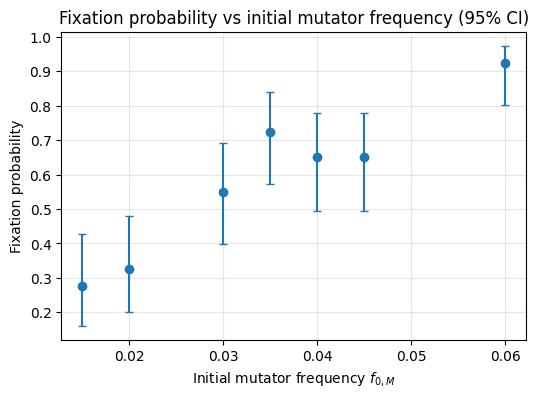

In [ ]:
# SET THE PARAMETERS
# Possible choice of f0_M values
f0_M_values =  [15/1000, 20/1000, 30/1000, 35/1000, 40/1000, 45/1000, 60/1000]
T = 1000*140          # Time horizon
n_sim = 40            # Number of independent simulations
N = 1000              # Population size
d = 2                 # Phenotypic dimensionality
mu_WT = 2e-4          # Mutation rate of wild type
alpha = 200           # Mutator strength (mu_M = alpha * mu_WT)
eta = 0.1             # Typical mutational effect size
sigma = 1.0           # Width of the fitness peak
w0_target = 0.5       # initial fitness
k = 2                 # Mutational pleiotropy

base_sim_params = dict(
    N=N,
    d=d,
    T=T,
    mu_WT=mu_WT,
    alpha=alpha,
    eta=eta,
    sigma=sigma,
    k = k,
    stop_on_fixation=True,
    w0_target = w0_target,
)

f0_M_results = parameter_sweep(
    param_name="f0_M",
    param_values=f0_M_values,
    base_params=base_sim_params,
    n_sim=n_sim,
)

# Estimate probability of fixation with Wilson CI
fix_probs = []
fix_ci_low = []
fix_ci_high = []

seed_rep_by_f0 = {}
state_rep_by_f0 = {}

for f in f0_M_values:
    n_fix = f0_M_results[f]["n_fix"]
    n_sim = f0_M_results[f]["n_sim"]
    # Compute empirical estimation of the fixation probability
    p_fix = n_fix / n_sim

    if p_fix >= 0.5:
        #  Fixation is prevaling
        seed_rep = representative_seed(
            f0_M_results[f]["fix_seeds"],
            f0_M_results[f]["t_abs_fix"]
        )
        state_rep = "fixation"
    else:
        # Exastinction is prevaling
        seed_rep = representative_seed(
            f0_M_results[f]["ext_seeds"],
            f0_M_results[f]["t_abs_ext"]
        )
        state_rep = "extinction"

    seed_rep_by_f0[f] = seed_rep
    state_rep_by_f0[f] = state_rep


    # Compute Wilson CI for the estimated probability
    low, high = proportion_confint(
        count=n_fix,
        nobs=n_sim,
        alpha=0.05,
        method="wilson"
    )

    fix_probs.append(p_fix)
    fix_ci_low.append(low)
    fix_ci_high.append(high)


yerr = [
    np.array(fix_probs) - np.array(fix_ci_low),
    np.array(fix_ci_high) - np.array(fix_probs)
]

plt.figure(figsize=(6,4))
plt.errorbar(
    f0_M_values,
    fix_probs,
    yerr=yerr,
    fmt="o",
    capsize=3
)
plt.xlabel(r"Initial mutator frequency $f_{0,M}$")
plt.ylabel("Fixation probability")
plt.title("Fixation probability vs initial mutator frequency (95% CI)")
plt.grid(True, alpha=0.3)
plt.show()


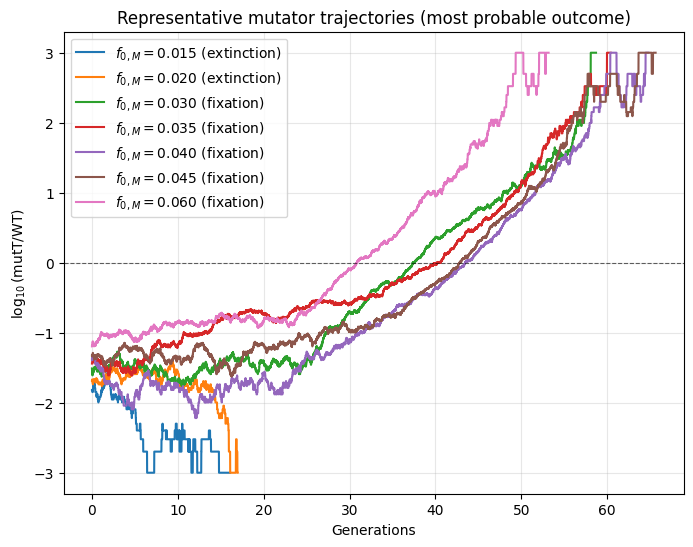

In [ ]:
plt.figure(figsize=(8,6))

for f in f0_M_values:
    params = base_sim_params.copy()
    params["f0_M"] = f

    seed_rep = seed_rep_by_f0[f]
    state_rep = state_rep_by_f0[f]

    if seed_rep is None:
        continue

    results = run_simulation(**params, seed=seed_rep)
    freq_M = results["freq_M"]
    t_abs = results["t_abs"]

    freq = freq_M[:t_abs]
    eps = 1 / params["N"]
    R = log_ratio_mutT_mutp(freq, eps)

    G = np.arange(len(R)) / params["N"]

    plt.plot(
        G,
        R,
        lw=1.5,
        label=rf"$f_{{0,M}} = {f:.3f}$ ({state_rep})" 
    )

plt.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
plt.xlabel("Generations")
plt.ylabel(r"$\log_{10}(\mathrm{mutT}/\mathrm{WT})$")
plt.title("Representative mutator trajectories (most probable outcome)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Treshold is probably 0.030-0.040 for N = 1000


## QUESTION: The win of mutator alleles is affected by the initial distance from the optimum? (Close to the optimum the beneficial mutations are fewer, while the deleterious are more)

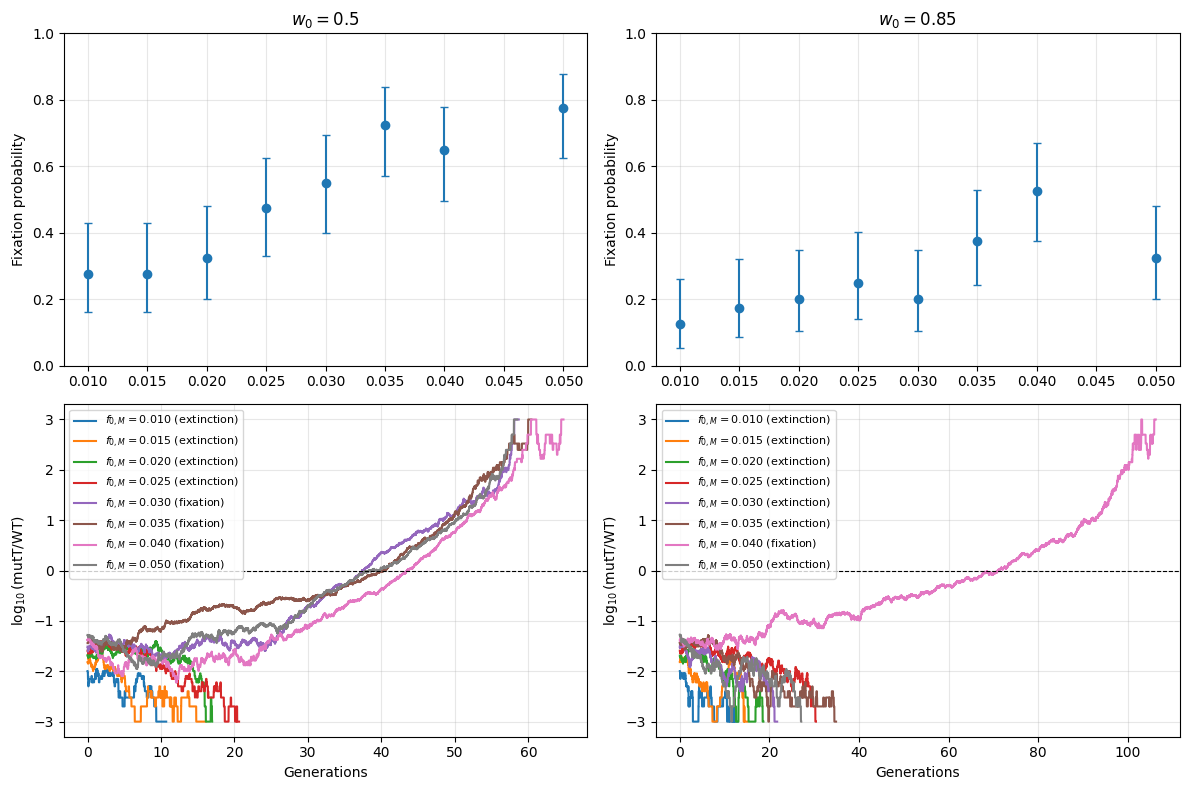

In [ ]:
# SET THE PARAMETERS
# Possible choice of f0_M values
f0_M_values =  [10/1000, 15/1000, 20/1000, 25/1000, 30/1000, 35/1000, 40/1000, 50/1000]
T = 1000*140          # Time horizon
n_sim =  40           # Number of independent simulations
N = 1000              # Population size
d = 2                 # Phenotypic dimensionality
mu_WT = 2e-4          # Mutation rate of wild type
alpha = 200           # Mutator strength (mu_M = alpha * mu_WT)
eta = 0.1             # Typical mutational effect size
sigma = 1.0           # Width of the fitness peak
w0_target = [0.5, 0.85]


# Figure setup
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


#  LOOP OVER w0
for col, w in enumerate(w0_target):

    base_sim_params = dict(
        N=N,
        d=d,
        T=T,
        mu_WT=mu_WT,
        alpha=alpha,
        eta=eta,
        sigma=sigma,
        stop_on_fixation=True,
        w0_target=w,
    )

    f0_M_results = parameter_sweep(
        param_name="f0_M",
        param_values=f0_M_values,
        base_params=base_sim_params,
        n_sim=n_sim,
    )

    # reset containers FOR THIS w0
    fix_probs = []
    fix_ci_low = []
    fix_ci_high = []
    seed_rep_by_f0 = {}
    state_rep_by_f0 = {}

    # Fixation probabilities
    for f in f0_M_values:
        n_fix = f0_M_results[f]["n_fix"]
        n_sim_local = f0_M_results[f]["n_sim"]

        p_fix = n_fix / n_sim_local

        if p_fix >= 0.5:
            seed_rep = representative_seed(
                f0_M_results[f]["fix_seeds"],
                f0_M_results[f]["t_abs_fix"]
            )
            state_rep = "fixation"
        else:
            seed_rep = representative_seed(
                f0_M_results[f]["ext_seeds"],
                f0_M_results[f]["t_abs_ext"]
            )
            state_rep = "extinction"

        seed_rep_by_f0[f] = seed_rep
        state_rep_by_f0[f] = state_rep

        low, high = proportion_confint(
            count=n_fix,
            nobs=n_sim_local,
            alpha=0.05,
            method="wilson"
        )

        fix_probs.append(p_fix)
        fix_ci_low.append(low)
        fix_ci_high.append(high)



    yerr = [
        np.array(fix_probs) - np.array(fix_ci_low),
        np.array(fix_ci_high) - np.array(fix_probs)
    ]

    ax = axes[0, col]
    ax.errorbar(
        f0_M_values,
        fix_probs,
        yerr=yerr,
        fmt="o",
        capsize=3
    )


    ax.set_title(rf"$w_0 = {w}$")
    ax.set_ylabel("Fixation probability")
    ax.grid(alpha=0.3)

    # Representative trajectories
    ax = axes[1, col]

    for f in f0_M_values:
        params = base_sim_params.copy()
        params["f0_M"] = f

        seed_rep = seed_rep_by_f0[f]
        state_rep = state_rep_by_f0[f]

        if seed_rep is None:
            continue

        results = run_simulation(**params, seed=seed_rep)
        freq_M = results["freq_M"]
        t_abs = results["t_abs"]

        freq = freq_M[:t_abs]
        eps = 1 / params["N"]
        R = log_ratio_mutT_mutp(freq, eps)

        G = np.arange(len(R)) / params["N"]

        ax.plot(
            G,
            R,
            lw=1.5,
            label=rf"$f_{{0,M}} = {f:.3f}$ ({state_rep})"
        )

    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Generations")
    ax.set_ylabel(r"$\log_{10}(\mathrm{mutT}/\mathrm{WT})$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)



for c in range(2):
    axes[0, c].set_ylim(0, 1)


plt.tight_layout()
plt.show()


## EXPERIMENT: Effect of mutator strength α and the cost of high mutation rates

While several experimental and theoretical studies have shown that increasing the genomic mutation rate can accelerate adaptation by increasing the supply of beneficial mutations, it remains unclear whether this advantage persists at arbitrarily high mutation rates. A variety of models suggest that extremely high mutation rates may hinder adaptation by generating an excessive load of deleterious mutations. Early theoretical work predicted the existence of a critical “error threshold”, beyond which population fitness declines as mutation rate increases:, although the exact nature of this threshold depends on model assumptions.

Here, we investigate whether a similar trade-off emerges in an individual-based model combining a non-neutral Moran process with Fisher’s Geometrical Model. In particular, we ask whether increasing the mutator strength α leads to diminishing returns or reduced adaptive success, even in the absence of an explicit fitness cost associated with the mutator allele.
Reference: https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1007324

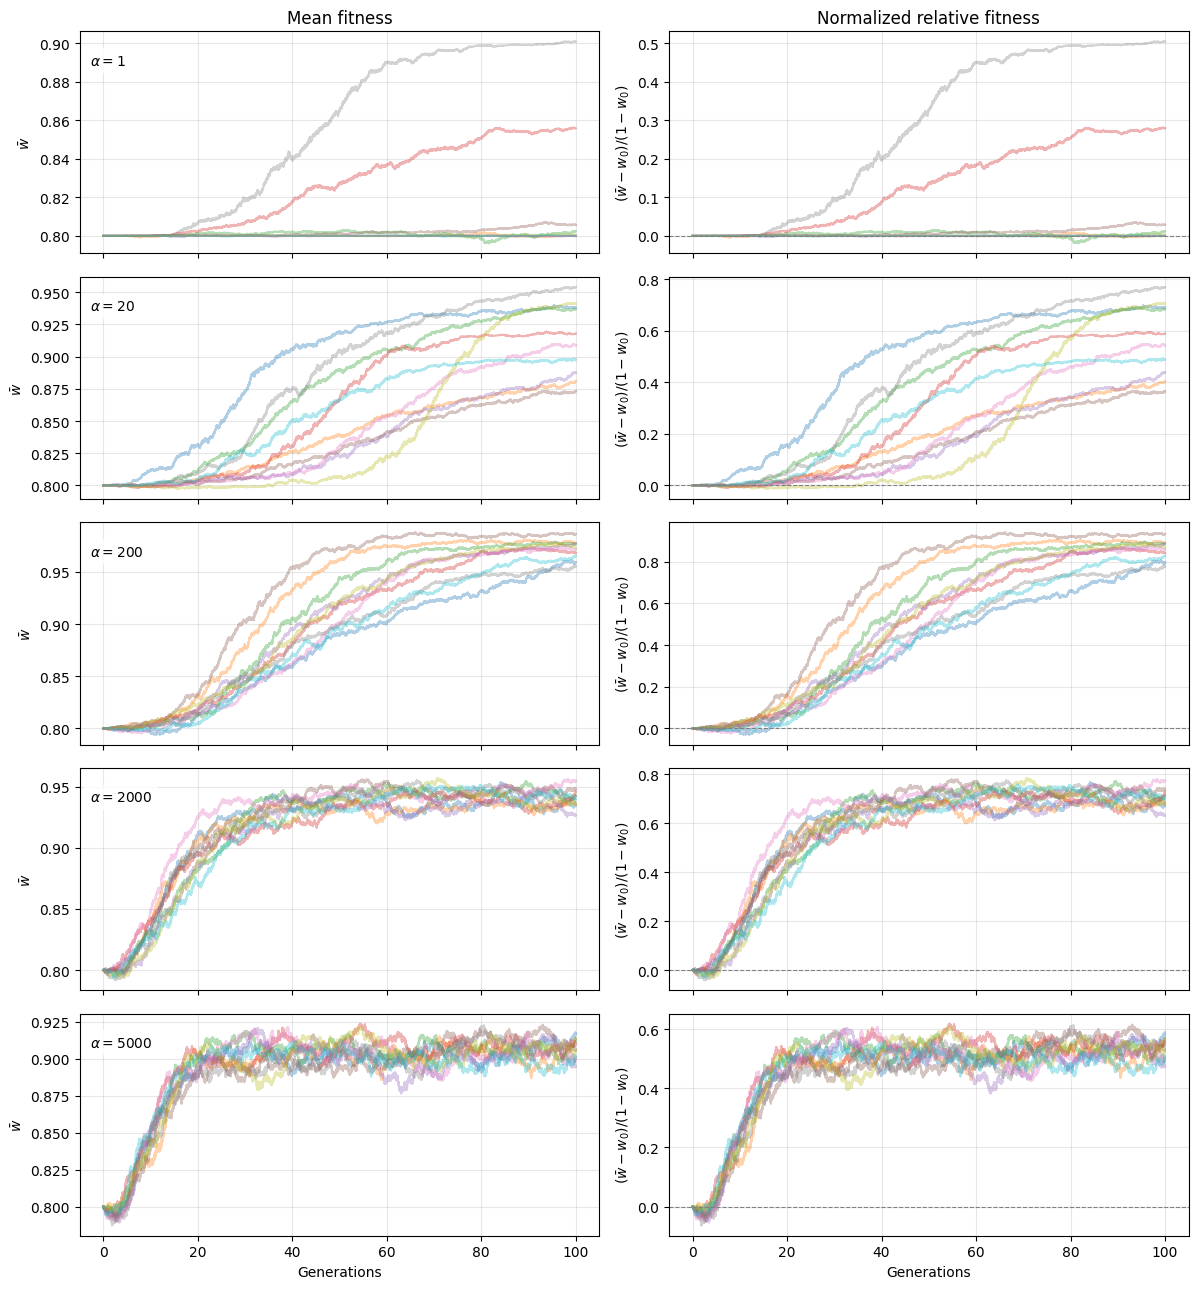

In [ ]:
# PARAMETERS
alpha_plot = [1, 20, 200, 2000, 5000]
f0_M = 1.0
T = 1000 * 100
n_sim = 10
N = 1000
d = 2
mu_WT = 2e-4
eta = 0.1
sigma = 1.0
w0 = 0.8

base_sim_params = dict(
    N=N,
    d=d,
    T=T,
    mu_WT=mu_WT,
    f0_M=f0_M,
    eta=eta,
    sigma=sigma,
    stop_on_fixation=False,
    w0_target=w0,
)


# RUN SIMULATIONS ONCE

results_by_alpha = {}

for alpha in alpha_plot:
    results_by_alpha[alpha] = []
    for seed in range(n_sim):
        params = base_sim_params.copy()
        params["alpha"] = alpha
        params["seed"] = seed
        res = run_simulation(**params)
        results_by_alpha[alpha].append(res)


# PLOT TABLE: mean fitness vs normalized relative fitness

n_alpha = len(alpha_plot)

fig, axes = plt.subplots(
    n_alpha, 2,
    figsize=(12, 2.6 * n_alpha),
    sharex="col"
)

for i, alpha in enumerate(alpha_plot):

    results = results_by_alpha[alpha]

    # LEFT COLUMN: MEAN FITNESS
    ax_left = axes[i, 0]
    for res in results:
        wbar = res["mean_fitness"]
        G = np.arange(len(wbar)) / N
        ax_left.plot(G, wbar, alpha=0.35)

    ax_left.set_ylabel(r"$\bar w$")
    ax_left.grid(alpha=0.3)

    if i == 0:
        ax_left.set_title("Mean fitness")
    ax_left.text(
        0.02, 0.85, rf"$\alpha = {alpha}$",
        transform=ax_left.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    # RIGHT COLUMN: NORMALIZED RELATIVE FITNESS
    ax_right = axes[i, 1]
    for res in results:
        wbar = res["mean_fitness"]
        delta_w_norm = (wbar - w0) / (1 - w0)
        G = np.arange(len(wbar)) / N
        ax_right.plot(G, delta_w_norm, alpha=0.35)

    ax_right.axhline(0, color="gray", lw=0.8, ls="--")
    ax_right.set_ylabel(r"$(\bar w - w_0)/(1 - w_0)$")
    ax_right.grid(alpha=0.3)

    if i == 0:
        ax_right.set_title("Normalized relative fitness")

# X labels only on bottom row
axes[-1, 0].set_xlabel("Generations")
axes[-1, 1].set_xlabel("Generations")

plt.tight_layout()
plt.show()


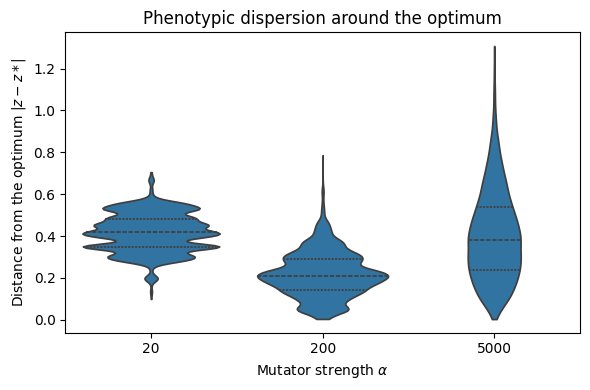

In [ ]:
# DISTRIBUTION OF DISTANCE FROM OPTIMUM
alpha_plot = [20, 200, 5000]
records = []

for alpha in alpha_plot:
    for res in results_by_alpha[alpha]:

        Z = res["Z_final"] if "Z_final" in res else None

        z_opt = res["zopt"][-1]

        distances = np.linalg.norm(Z - z_opt, axis=1)

        for r in distances:
            records.append({
                "alpha": alpha,
                "distance": r
            })

df = pd.DataFrame(records)

plt.figure(figsize=(6, 4))
sns.violinplot(
    data=df,
    x="alpha",
    y="distance",
    inner="quartile",
    cut=0
)
plt.xlabel(r"Mutator strength $\alpha$")
plt.ylabel(r"Distance from the optimum $|z -  z*|$")
plt.title("Phenotypic dispersion around the optimum")
plt.tight_layout()
plt.show()


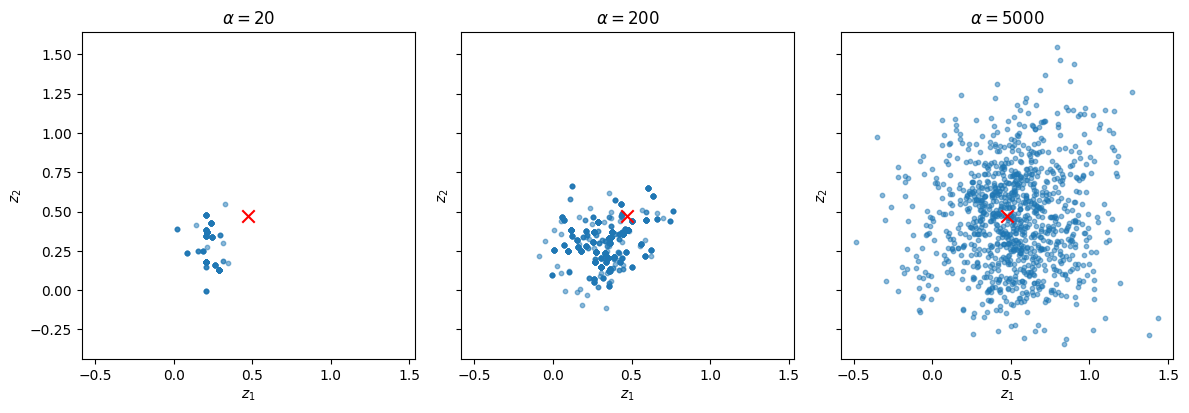

In [ ]:
fig, axes = plt.subplots(1, len(alpha_plot), figsize=(4*len(alpha_plot), 4), sharex=True, sharey=True)

for ax, alpha in zip(axes, alpha_plot):

    res = results_by_alpha[alpha][0]
    Z = res["Z_final"]
    zopt = res["zopt"][-1]

    ax.scatter(Z[:,0], Z[:,1], s=10, alpha=0.5)
    ax.scatter(zopt[0], zopt[1], c="red", marker="x", s=80)

    ax.set_title(rf"$\alpha={alpha}$")
    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## QUESTION: What is the effect of increasing the mutator strength on the competition between mutators and wild type?

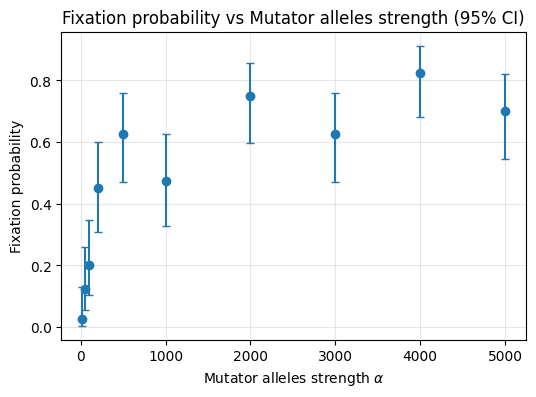


=== Logistic regression results ===

Linear model:
                           Logit Regression Results                           
Dep. Variable:                    fix   No. Observations:                  378
Model:                          Logit   Df Residuals:                      376
Method:                           MLE   Df Model:                            1
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                  0.1742
Time:                        08:21:30   Log-Likelihood:                -216.33
converged:                       True   LL-Null:                       -261.96
Covariance Type:            nonrobust   LLR p-value:                 1.252e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9252      0.489     -8.023      0.000      -4.884      -2.966
log_alpha      1.4209      0.168      8.459      0.000       1.092       1.750


In [ ]:
# SET THE PARAMETERS
# Possible choice of alpha values (mutator strength)
alpha_values = [20, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
f0_M =  35/1000       # Initial mutator allele frequency
T = 1000*140          # Time horizon
n_sim = 40            # Number of independent simulations
N = 1000              # Population size
d = 2                 # Phenotypic dimensionality
mu_WT = 2e-4          # Mutation rate of wild type
eta = 0.1             # Typical mutational effect size
sigma = 1.0           # Width of the fitness peak
w0 = 0.8              # Initial fitness

base_sim_params = dict(
    N=N,
    d=d,
    T=T,
    mu_WT=mu_WT,
    f0_M=f0_M,
    eta=eta,
    sigma=sigma,
    stop_on_fixation=True,
    w0_target = w0,
)
alpha_results = parameter_sweep(
    param_name="alpha",
    param_values=alpha_values,
    base_params=base_sim_params,
    n_sim=n_sim,
)
# Estimate probability of fixation with Wilson CI
fix_probs = []
fix_ci_low = []
fix_ci_high = []

seed_rep_by_alpha = {}
state_rep_by_alpha = {}

for a in alpha_values:
    n_fix = alpha_results[a]["n_fix"]
    n_sim = alpha_results[a]["n_sim"]
    # Compute empirical estimation of the fixation probability
    p_fix = n_fix / n_sim

    if p_fix >= 0.5:
        #  Fixation is prevaling
        seed_rep = representative_seed(
            alpha_results[a]["fix_seeds"],
            alpha_results[a]["t_abs_fix"]
        )
        state_rep = "fixation"
    else:
        # Exastinction is prevaling
        seed_rep = representative_seed(
            alpha_results[a]["ext_seeds"],
            alpha_results[a]["t_abs_ext"]
        )
        state_rep = "extinction"

    seed_rep_by_alpha[a] = seed_rep
    state_rep_by_alpha[a] = state_rep


    # Compute Wilson CI for the estimated probability
    low, high = proportion_confint(
        count=n_fix,
        nobs=n_sim,
        alpha=0.05,
        method="wilson"
    )

    fix_probs.append(p_fix)
    fix_ci_low.append(low)
    fix_ci_high.append(high)


yerr = [
    np.array(fix_probs) - np.array(fix_ci_low),
    np.array(fix_ci_high) - np.array(fix_probs)
]

plt.figure(figsize=(6,4))
plt.errorbar(
    alpha_values,
    fix_probs,
    yerr=yerr,
    fmt="o",
    capsize=3
)
plt.xlabel(r"Mutator alleles strength $\alpha$")
plt.ylabel("Fixation probability")
plt.title("Fixation probability vs Mutator alleles strength (95% CI)")
plt.grid(True, alpha=0.3)
plt.show()



# STATISTICAL TEST: Does fixation probability depend non-linearly on alpha?
# Build "long" dataset: one row per simulation


rows = []

for a in alpha_values:
    n_fix = alpha_results[a]["n_fix"]
    n_ext = alpha_results[a]["n_ext"]

    # fixation = 1
    for _ in range(n_fix):
        rows.append({
            "alpha": a,
            "log_alpha": np.log10(a),
            "fix": 1
        })

    # extinction = 0
    for _ in range(n_ext):
        rows.append({
            "alpha": a,
            "log_alpha": np.log10(a),
            "fix": 0
        })

df = pd.DataFrame(rows)


# Logistic regression – linear model
# logit(p) = beta0 + beta1 * log10(alpha)


X_lin = sm.add_constant(df["log_alpha"])
model_lin = sm.Logit(df["fix"], X_lin).fit(disp=False)


# Logistic regression – quadratic model
# logit(p) = beta0 + beta1 * log10(alpha) + beta2 * log10(alpha)^2

df["log_alpha2"] = df["log_alpha"]**2
X_quad = sm.add_constant(df[["log_alpha", "log_alpha2"]])
model_quad = sm.Logit(df["fix"], X_quad).fit(disp=False)


# Likelihood Ratio Test
LR_stat = 2 * (model_quad.llf - model_lin.llf)
df_diff = model_quad.df_model - model_lin.df_model
p_value = chi2.sf(LR_stat, df_diff)


# Print results
print("\n=== Logistic regression results ===\n")

print("Linear model:")
print(model_lin.summary())

print("\nQuadratic model:")
print(model_quad.summary())

print("\n=== Likelihood Ratio Test ===")
print(f"LR statistic = {LR_stat:.3f}")
print(f"Degrees of freedom = {df_diff}")
print(f"p-value = {p_value:.4g}")

if p_value < 0.05:
    print("\n➡ Evidence for a NON-LINEAR dependence of fixation probability on alpha.")
else:
    print("\n➡ No significant evidence for non-linearity in fixation probability.")


## EFFECT OF ENVIRONMENTAL CHANGES (Moving Optimum)

In [ ]:
def stepwise_moving_zopt(z0, v, interval):
    def zopt(t):
        steps = t // interval
        t_effective = steps * interval
        return z0 + v * t_effective
    return zopt

Starting simulation 1/4 with v=0.0032...
Starting simulation 2/4 with v=0.0001...
Starting simulation 3/4 with v=1e-05...
Starting simulation 4/4 with v=1e-08...


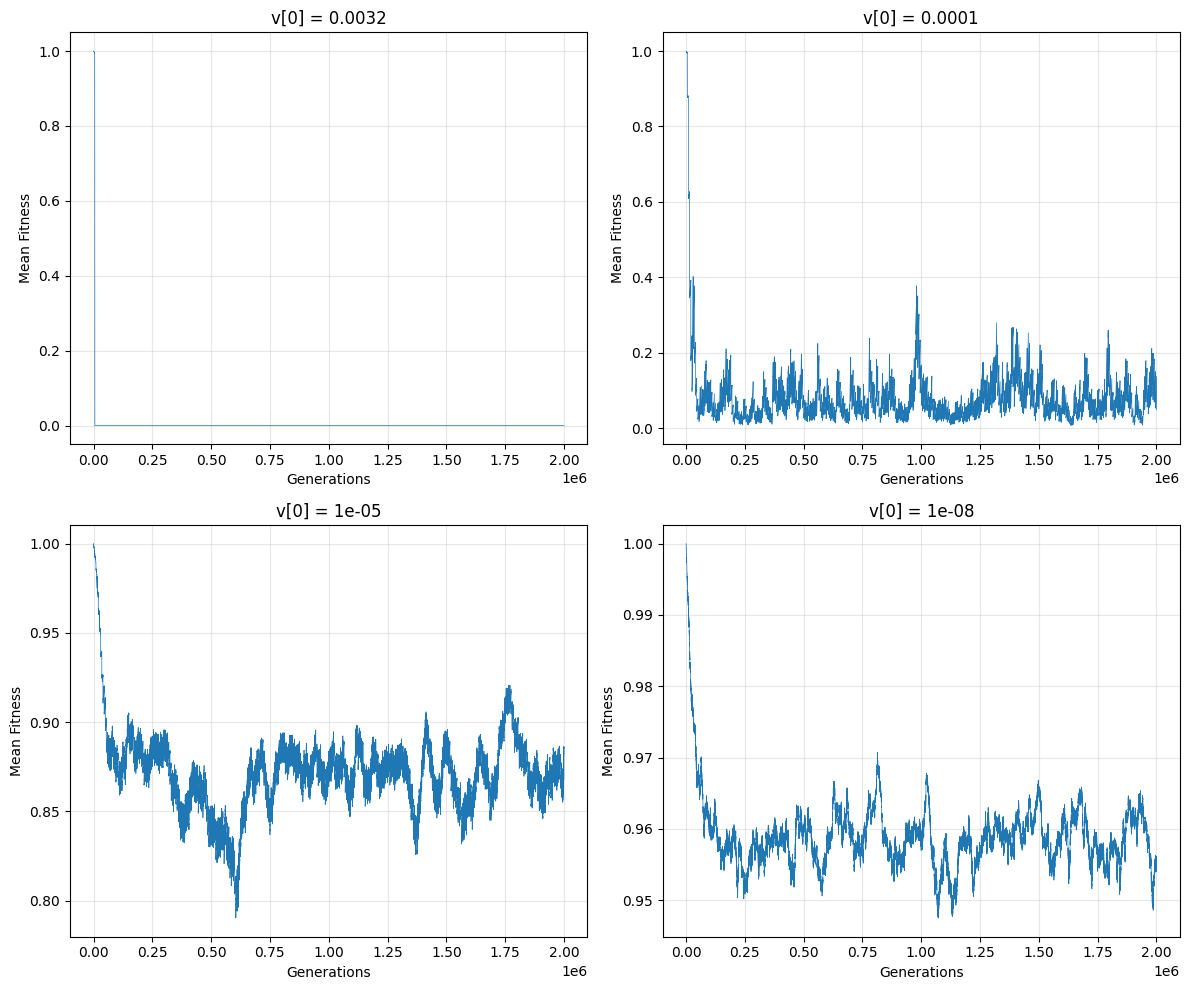

In [ ]:
# Parameters
d = 2
sigma = 1.0
interval = 5000 # every 5 thousand iterations, the optimum moves

# Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

velocities = [0.0032, 1e-4, 1e-5, 1e-8] # vector of velocities to test

for idx, val in enumerate(velocities):

    v = np.zeros(d)
    v[0] = val # v is all zeros except for the first component
    z0 = np.zeros(d) # starting optimum position: here we start from 0

    base_sim_params = dict(
        N=2000,
        d=d,
        T=2000000, # long time to see the stabilization and the lag
        mu_WT=2e-1, # high mutation rate to see earlier and better the population response
        alpha=200,
        zopt_fn=stepwise_moving_zopt(z0, v, interval),
        eta=0.1,
        sigma=sigma,
        k=2,
        stop_on_fixation=False
    )

    print(f"Starting simulation {idx+1}/4 with v={val}...")
    res = run_simulation(**base_sim_params, seed=3)

    ax = axs[idx]
    ax.plot(res["mean_fitness"], color='tab:blue',linewidth=0.5)
    ax.set_title(f"v[0] = {val}")
    ax.set_xlabel("Generations")
    ax.set_ylabel("Mean Fitness")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PUNCTUATED EQUILIBRIUM DYNAMICS
Punctuated equilibria (PE) is a theory of evolution proposed by Eldredge & Gould (1972) that suggests that species undergo periods of stasis (no significant change) followed by punctuated changes (rapid phenotypic change)

In [ ]:
## SET THE PARAMETERS ##
T = 1000*1000      # Time horizon
N = 1000           # Population size
d = 2              # Phenotypic dimensionality
f0_M = 0           # Initial mutator frequency
mu_WT = 2e-4       # Mutation rate of wild type
alpha = 1          # Mutator strength (mu_M = alpha * mu_WT)
eta = 0.1          # Typical mutational effect size
sigma = 1.0        # Width of the fitness peak
w0_target = 0.3    # initial fitness

res = run_simulation(
    N=N, d=d, T=T,
    f0_M=f0_M,
    mu_WT=mu_WT,
    alpha=alpha,
    eta=eta,
    sigma=sigma,
    seed=3,
    w0_target = w0_target,
    stop_on_fixation = False
)

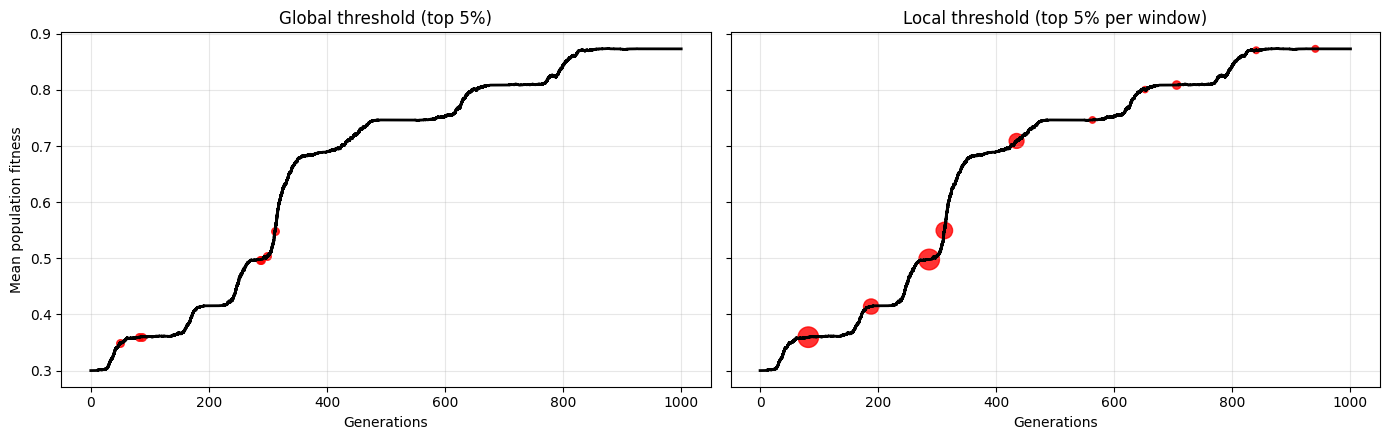

In [ ]:
# Mean fitness and mean distance
mean_fitness = res["mean_fitness"]

# Get information about mutations
mut_log = res["log"]["mutations"]

# Time axis in generations
G = np.arange(len(mean_fitness)) / N

# Beneficial mutations
ben = [m for m in mut_log if m["beneficial"]]

# Global criterion: top 5% beneficial mutations overall

s_values = np.array([m["s_pop"] for m in ben])
s_thr_global = np.percentile(s_values, 95)

t_global = [m["t"] for m in ben if m["s_pop"] >= s_thr_global]
G_global = np.array(t_global) / N
fit_global = [mean_fitness[t] for t in t_global]


# Local criterion: top 5% per time window


window_gen = 100
window_steps = window_gen * N

t_local = []
s_local = []

for t0 in range(0, T, window_steps):
    t1 = min(t0 + window_steps, T)

    ben_win = [m for m in ben if t0 <= m["t"] < t1]
    if len(ben_win) < 5:
        continue

    s_vals = np.array([m["s_pop"] for m in ben_win])
    s_thr = np.percentile(s_vals, 95)

    for m in ben_win:
        if m["s_pop"] >= s_thr:
            t_local.append(m["t"])
            s_local.append(m["s_pop"])

G_local = np.array(t_local) / N
fit_local = [mean_fitness[t] for t in t_local]

# Point size proportional to absolute effect size
s_local = np.array(s_local)
sizes_local = 20 + 200 * (s_local - s_local.min()) / (s_local.max() - s_local.min() + 1e-12)


# Plot Mean Fitness
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

# Global threshold
axes[0].plot(G, mean_fitness, lw=2, color="black")
axes[0].scatter(G_global, fit_global, color="red", s=30, alpha=0.8)
axes[0].set_title("Global threshold (top 5%)")
axes[0].set_xlabel("Generations")
axes[0].set_ylabel("Mean population fitness")
axes[0].grid(alpha=0.3)

# Local threshold
axes[1].plot(G, mean_fitness, lw=2, color="black")
axes[1].scatter(G_local, fit_local, s=sizes_local, color="red", alpha=0.8)
axes[1].set_title("Local threshold (top 5% per window)")
axes[1].set_xlabel("Generations")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## EFFECT OF PHENOTYPIC DIMENSIONALITY
We try to explore the effect of changing the phenotypic dimensionality in our model, keeping all other evolutionary parameters fixed.
To isolate the effect of phenotypic dimensionality on the adaptive dynamics predicted by Fisher’s Geometrical Model, we exclude mutator allele dynamics in the following simulations by setting the initial mutator frequency to zero $f_{0,M} = 0$.
We study the effect of increasing d by assuming the same mean fitness effect of mutations $E(S)= -k\eta^2.$ for each value of d, i.e considering partial pleiotropy (k = 3) and same $\eta = \sqrt(0.004)$, as in the reference paper DOI 10.7717/peerj.2256. This allows us to attribute observed differences in the adaptive dynamics solely to changes in phenotypic dimensionality.

/tmp/ipython-input-965643567.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


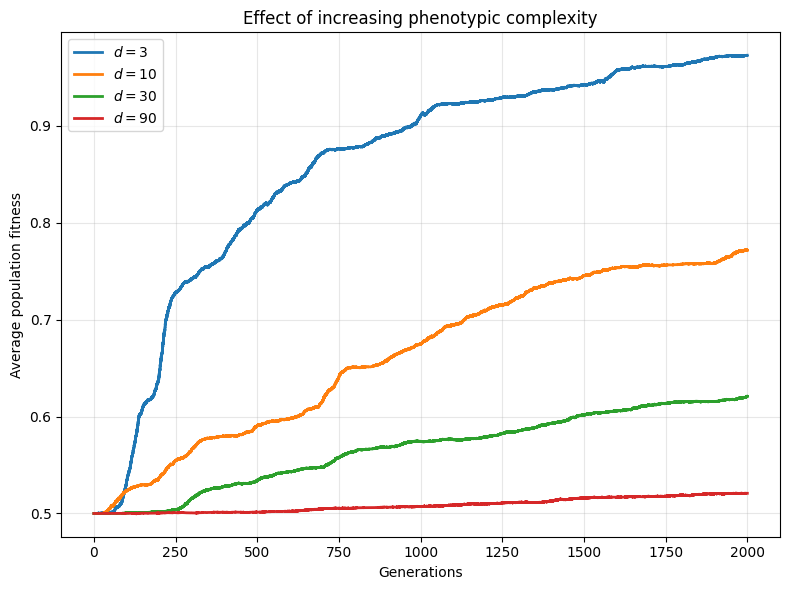

In [ ]:
# SET THE PARAMETERS
# Possible choice of d values (phenotypic dimensionality)
d_values = [3, 10, 30, 90]
f0_M =  0             # initial mutator allele frequency
T = 1000*2000         # time horizon
N = 1000              # Population size
alpha = 1.0           # mutator strength
mu_WT = 0.001         # Mutation rate of wild type
eta = np.sqrt(0.004)  # std of the distribution of the effect of mutations
k = 3                 # mutational pleiotropy
w0_target = 0.5       # initial fitness
sigma = 1.0           # width of the fitness peak
n_sim = 3             # number of simulations

mean_fitness_by_d = {}
s_by_d = {d: [] for d in d_values}

for d in d_values:
    mf_runs = []

    for seed in range(n_sim):
        res = run_simulation(
            N=N, d=d, T=T,
            f0_M=f0_M,
            mu_WT=mu_WT,
            alpha=alpha,
            eta=eta,
            sigma=sigma,
            k=k,
            seed=seed,
            stop_on_fixation=False,
            w0_target=w0_target
        )
        mf_runs.append(res["mean_fitness"])
        # Extract s for THIS simulation
        for mut in res["log"]["mutations"]:
            s_by_d[d].append(mut["s"])

    mf_runs = np.array(mf_runs)        # shape (n_sim, T+1)
    mean_fitness_by_d[d] = mf_runs.mean(axis=0)


# Plot mean fitness vs generations for each d
G = np.arange(T + 1) / N
plt.figure(figsize=(8, 6))

for d, mf in mean_fitness_by_d.items():
    plt.plot(G, mf, lw=2, label=rf"$d = {d}$")

plt.xlabel("Generations")
plt.ylabel("Average population fitness")
plt.title("Effect of increasing phenotypic complexity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()